# Employee Turnover Analytics

Course-end capstone project for Portobello Tech HR Department.

*Sections marked with \* are supplementary analysis added beyond the assignment's required scope.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

from imblearn.over_sampling import SMOTE

%matplotlib inline


In [2]:
df = pd.read_csv('HR_comma_sep.csv')

print(df.shape)
df.head()


(14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


In [4]:
df['sales'].value_counts()


sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [5]:
df['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [6]:
df = df.rename(columns={
    'sales': 'Department',
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident'
})

print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())


Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Duplicate rows: 3008


In [7]:
df = df.drop_duplicates()
print('Shape after dropping duplicates:', df.shape)


Shape after dropping duplicates: (11991, 10)


In [8]:
df['Department'].value_counts()

Department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

In [9]:
#department value counts for [left=1]
df[df['left'] == 1]['Department'].value_counts()


Department
sales          550
technical      390
support        312
IT             158
hr             113
marketing      112
product_mng    110
accounting     109
RandD           85
management      52
Name: count, dtype: int64

In [10]:
df[df['left'] == 0]['Department'].value_counts()

Department
sales          2689
technical      1854
support        1509
IT              818
RandD           609
product_mng     576
marketing       561
accounting      512
hr              488
management      384
Name: count, dtype: int64

## 2. EDA — what factors contribute most to employee turnover

### 2.1 Correlation heatmap


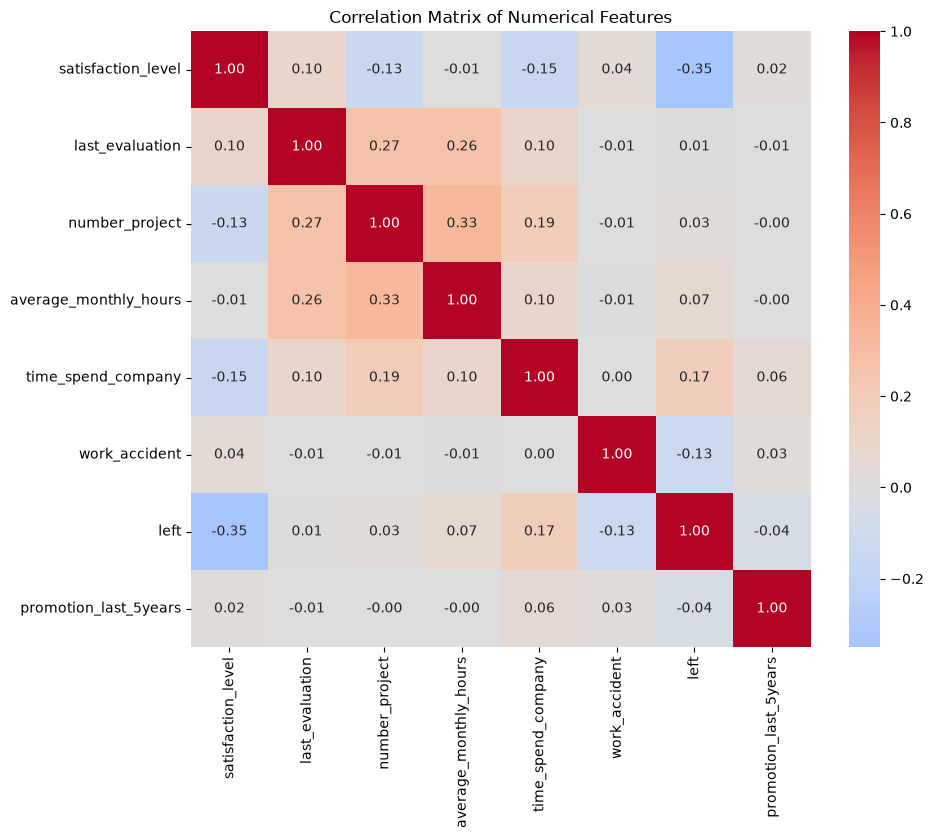

In [11]:
numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
                  'average_monthly_hours', 'time_spend_company', 'work_accident',
                  'left', 'promotion_last_5years']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### 2.2 Distribution plots


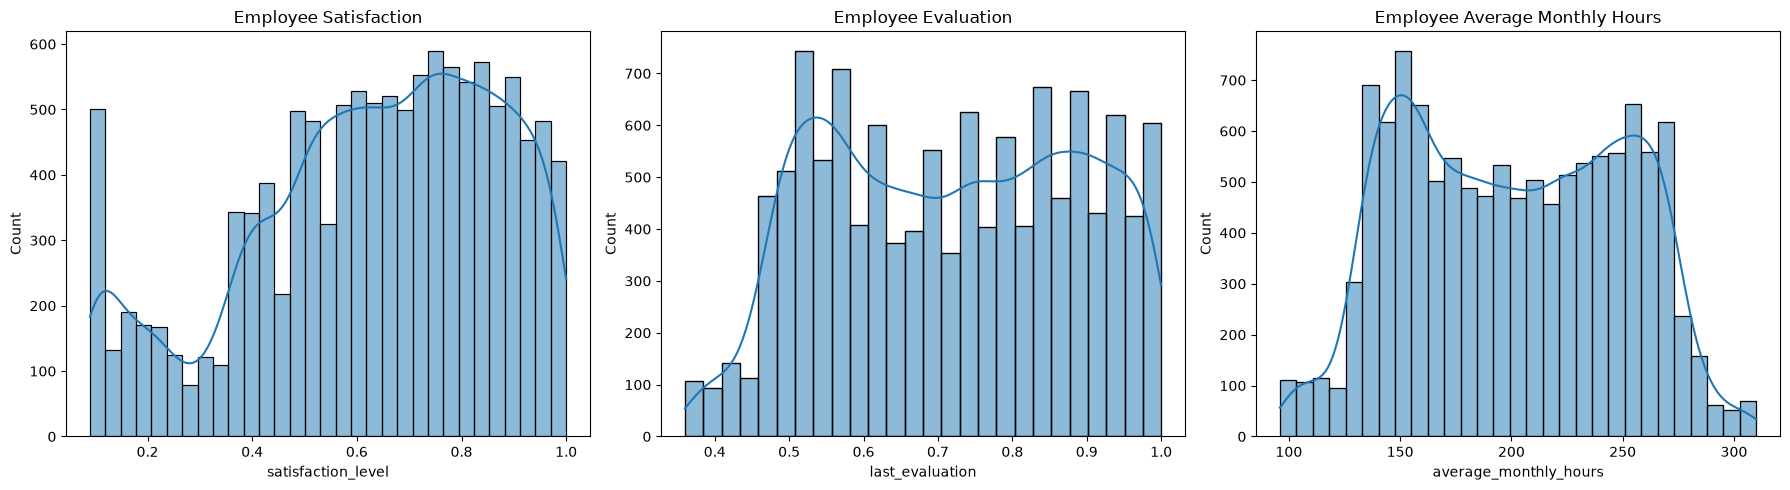

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0])
axes[0].set_title('Employee Satisfaction')

sns.histplot(df['last_evaluation'], kde=True, ax=axes[1])
axes[1].set_title('Employee Evaluation')

sns.histplot(df['average_monthly_hours'], kde=True, ax=axes[2])
axes[2].set_title('Employee Average Monthly Hours')

plt.tight_layout()
plt.show()


### 2.3 Project count by attrition status


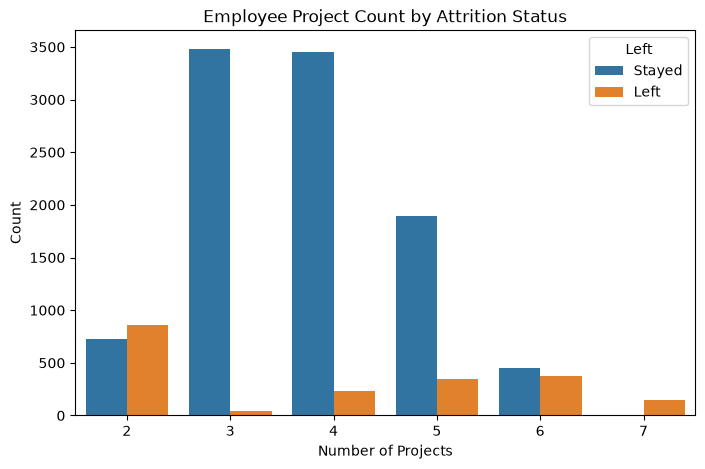

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title('Employee Project Count by Attrition Status')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.show()


**Inference:** Project count shows a bimodal pattern for employees who left, similar to average monthly hours. Employees with 3-4 projects have by far the lowest attrition (~1-6%), while employees with only 2 projects (54% leave) and employees with 6-7 projects (45-100% leave) both leave at high rates. This suggests two distinct at-risk groups: underutilized/disengaged employees on too few projects, and overloaded employees on too many.


### 2.4\* Turnover rate by department and salary level

*Supplementary analysis — Department and salary weren't covered in 2.1-2.3; this adds a dimension the retention strategy in Step 7 can draw on.*

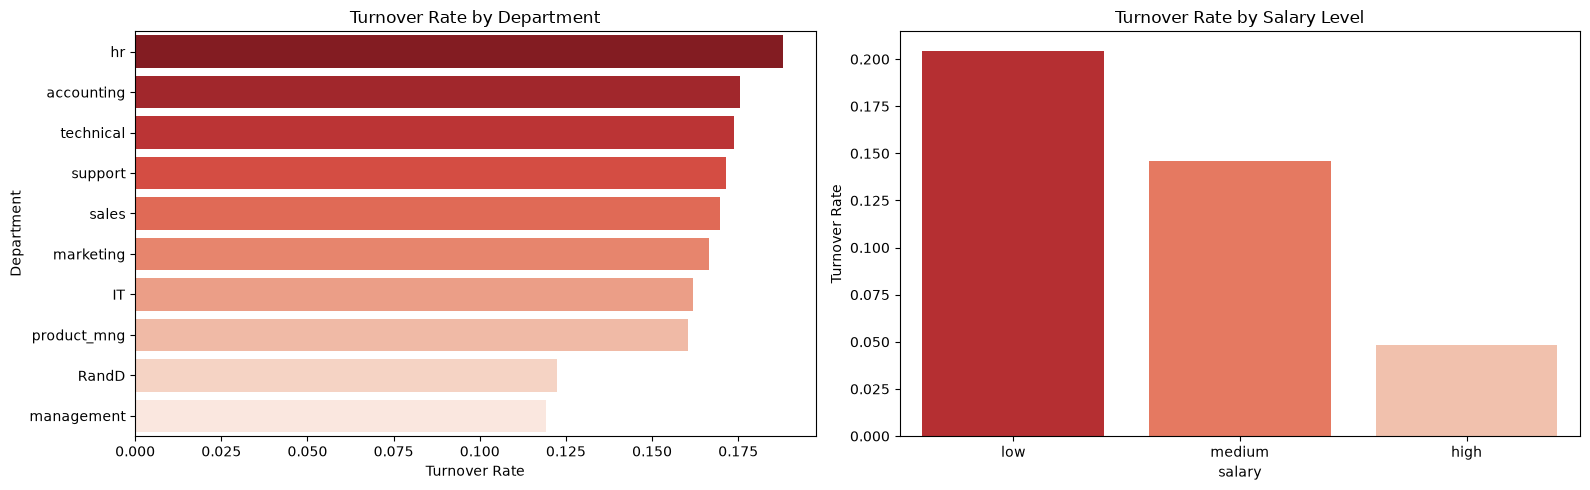

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dept_rate = df.groupby('Department')['left'].mean().sort_values(ascending=False)
sns.barplot(x=dept_rate.values, y=dept_rate.index, hue=dept_rate.index, palette='Reds_r', legend=False, ax=axes[0])
axes[0].set_title('Turnover Rate by Department')
axes[0].set_xlabel('Turnover Rate')

salary_rate = df.groupby('salary')['left'].mean().reindex(['low', 'medium', 'high'])
sns.barplot(x=salary_rate.index, y=salary_rate.values, hue=salary_rate.index, palette='Reds_r', legend=False, ax=axes[1])
axes[1].set_title('Turnover Rate by Salary Level')
axes[1].set_ylabel('Turnover Rate')

plt.tight_layout()
plt.show()


## 3. Clustering employees who left, by satisfaction and evaluation


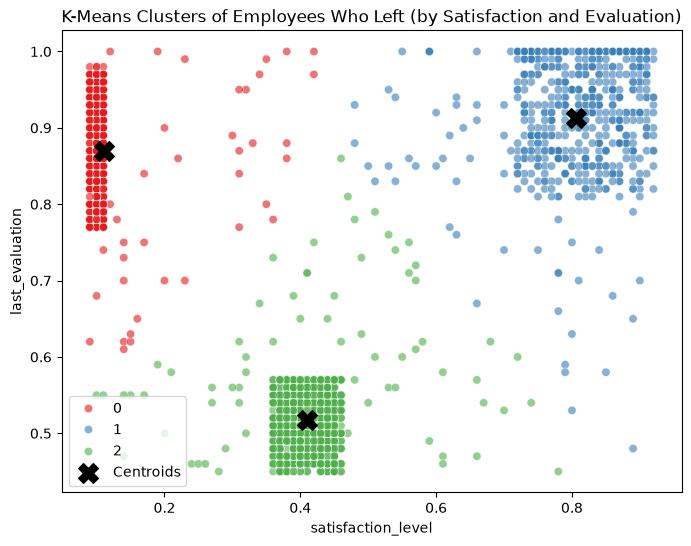

,satisfaction_level,last_evaluation
cluster,,
0,0.111199,0.869064
1,0.805874,0.912577
2,0.410133,0.517195


In [15]:
left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]

kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)
left_df = left_df.copy()
left_df['cluster'] = kmeans.fit_predict(left_df[['satisfaction_level', 'last_evaluation']])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', hue='cluster', palette='Set1', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clusters of Employees Who Left (by Satisfaction and Evaluation)')
plt.legend()
plt.show()

left_df.groupby('cluster')[['satisfaction_level', 'last_evaluation']].mean()


**Inference:** Three dense, distinct clusters emerge among employees who left:
- **Cluster 0 — low satisfaction (0.11), high evaluation (0.87):** high performers who were unhappy, likely burned out from heavy workload (ties to the project-count/hours findings above). *Action: rebalance workload.*
- **Cluster 1 — high satisfaction (0.81), high evaluation (0.91):** satisfied, well-rated employees who left anyway, likely for better opportunities elsewhere. *Action: proactive internal growth paths/promotions to retain top performers before competitors do.*
- **Cluster 2 — mid satisfaction (0.41), mid evaluation (0.52):** the least extreme group; reason for leaving isn't yet clear from these two features alone. *Action: needs further investigation, no clear lever yet.*

A single "improve satisfaction" strategy would miss two of these three groups — retention needs to be targeted per cluster.


### 3.4\* Validating k=3 with silhouette score

*Supplementary check — the assignment specifies k=3; this confirms it's a reasonable choice.*

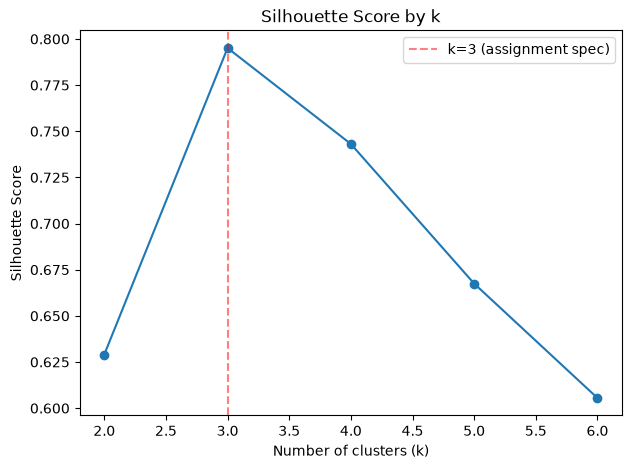

{2: 0.6290318078214997,
 3: 0.79511279122309,
 4: 0.7431153192496658,
 5: 0.6674862779715623,
 6: 0.6055032068541423}

In [16]:
from sklearn.metrics import silhouette_score

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(left_df[['satisfaction_level', 'last_evaluation']])
    sil_scores[k] = silhouette_score(left_df[['satisfaction_level', 'last_evaluation']], labels)

plt.figure(figsize=(7, 5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3 (assignment spec)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.legend()
plt.show()

sil_scores


## 4. Handling class imbalance with SMOTE

### 4.1 Encode categorical columns


In [17]:
categorical_cols = ['Department', 'salary']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['left']]

categorical_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
numeric_data = df[numeric_cols]

X = pd.concat([numeric_data, categorical_encoded], axis=1)
y = df['left']

print(X.shape)
X.head()


(11991, 18)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False


### 4.2 Stratified 80:20 train/test split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

print('Train class balance:')
print(y_train.value_counts(normalize=True))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True))


Train class balance:
left
0    0.833924
1    0.166076
Name: proportion, dtype: float64

Test class balance:
left
0    0.834098
1    0.165902
Name: proportion, dtype: float64


### 4.3 SMOTE the training set only


In [19]:
smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_sm.value_counts().to_dict())


Before SMOTE: {0: 7999, 1: 1593}
After SMOTE: {0: 7999, 1: 7999}


**Note\*:** Standard `SMOTE` interpolates all features numerically, including the one-hot dummy columns above — a synthetic row can end up with a dummy value like 0.37 instead of a clean 0/1. This is compliant with the assignment's "SMOTE technique" instruction, but for mixed categorical/numeric data, `SMOTENC` (SMOTE for Nominal and Continuous features) is the more methodologically correct tool, since it samples categorical features by majority vote among nearest neighbors instead of interpolating them.

## 5. 5-fold cross-validation model training


In [20]:
from sklearn.model_selection import cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

def plot_cv_classification_report(model, X, y, title):
    y_pred_cv = cross_val_predict(model, X, y, cv=cv)
    report = classification_report(y, y_pred_cv, output_dict=True)
    report_df = pd.DataFrame(report).T

    plt.figure(figsize=(6, 4))
    sns.heatmap(report_df.iloc[:, :-1], annot=True, fmt='.3f', cmap='Blues')
    plt.title(title)
    plt.show()

    return report_df


### 5.1 Logistic Regression


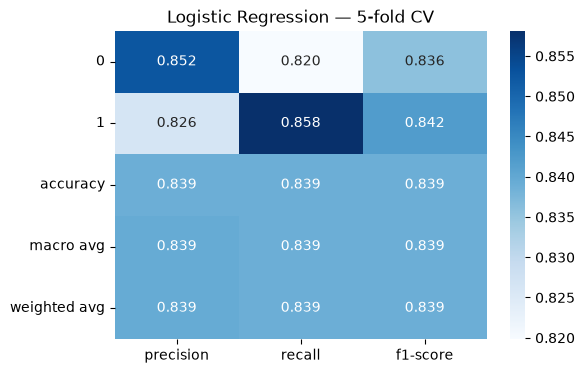

,precision,recall,f1-score,support
0,0.852463,0.819852,0.835840,7999.00000
1,0.826490,0.858107,0.842002,7999.00000
accuracy,0.838980,0.838980,0.838980,0.83898
macro avg,0.839477,0.838980,0.838921,15998.00000
weighted avg,0.839477,0.838980,0.838921,15998.00000


In [21]:
log_reg = LogisticRegression(max_iter=1000, random_state=123)
log_reg_report = plot_cv_classification_report(log_reg, X_train_sm, y_train_sm, 'Logistic Regression — 5-fold CV')
log_reg_report


### 5.2 Random Forest


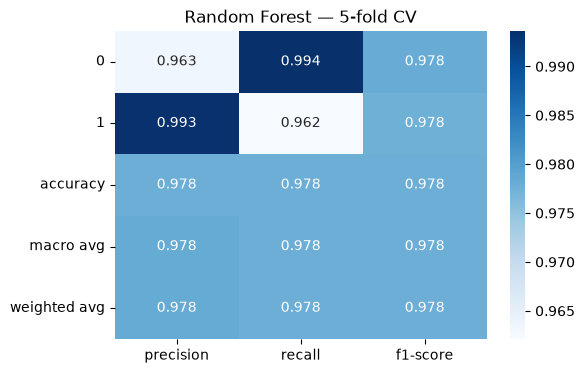

,precision,recall,f1-score,support
0,0.963277,0.993624,0.978215,7999.000000
1,0.993417,0.962120,0.977518,7999.000000
accuracy,0.977872,0.977872,0.977872,0.977872
macro avg,0.978347,0.977872,0.977867,15998.000000
weighted avg,0.978347,0.977872,0.977867,15998.000000


In [22]:
rf = RandomForestClassifier(random_state=123)
rf_report = plot_cv_classification_report(rf, X_train_sm, y_train_sm, 'Random Forest — 5-fold CV')
rf_report


### 5.3 Gradient Boosting


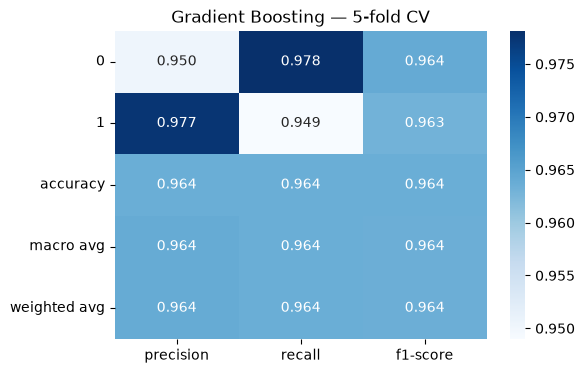

,precision,recall,f1-score,support
0,0.950437,0.978122,0.964081,7999.000000
1,0.977466,0.948994,0.963019,7999.000000
accuracy,0.963558,0.963558,0.963558,0.963558
macro avg,0.963952,0.963558,0.963550,15998.000000
weighted avg,0.963952,0.963558,0.963550,15998.000000


In [23]:
gbc = GradientBoostingClassifier(random_state=123)
gbc_report = plot_cv_classification_report(gbc, X_train_sm, y_train_sm, 'Gradient Boosting — 5-fold CV')
gbc_report


## 6. Identifying the best model

### 6.1 Fit each model on the full training set, evaluate ROC/AUC on the held-out test set


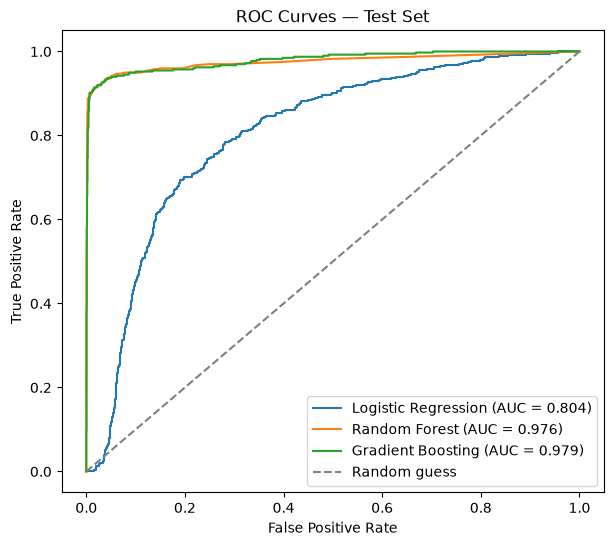

{'Logistic Regression': 0.8035065381881924,
 'Random Forest': 0.9756792458042336,
 'Gradient Boosting': 0.9790236791152161}

In [24]:
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'Gradient Boosting': gbc
}

plt.figure(figsize=(7, 6))
auc_scores = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Test Set')
plt.legend()
plt.show()

auc_scores


### 6.2 Confusion matrices


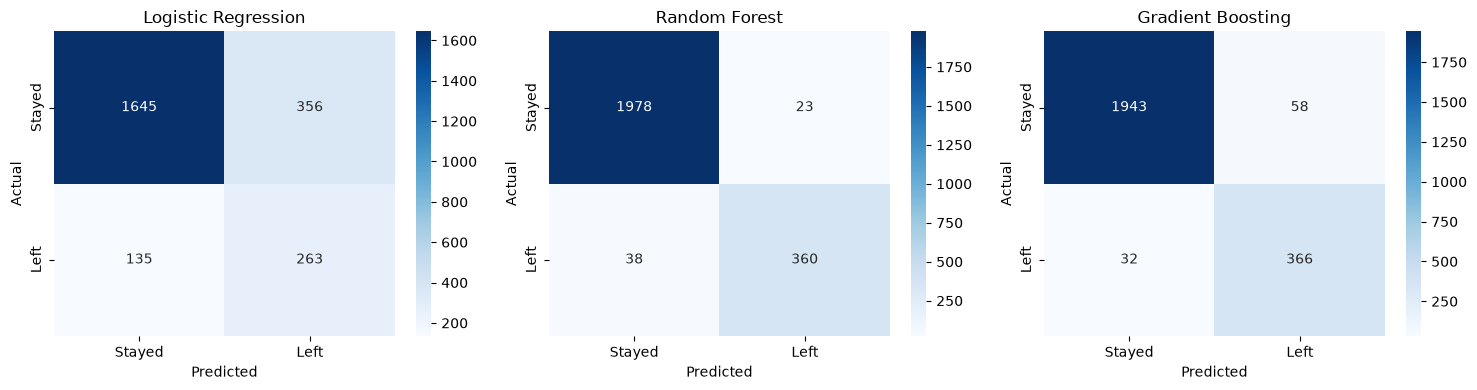

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


### 6.3 Best model and metric justification

**Metric choice — Recall over Precision:** In this business context, a false negative (predicting an employee will stay when they actually leave) is costly — the employee leaves with zero intervention. A false positive (predicting an employee will leave when they actually stay) is cheap — worst case, the company spends a bit of extra retention effort on someone who wasn't at risk. Since minimizing false negatives is the priority, **recall** (`TP/(TP+FN)`) is the metric that matters most here, not precision.

**Best model — Gradient Boosting:** AUC and 5-fold CV accuracy were close to tied between Random Forest and Gradient Boosting (within ~0.003-0.014, not a reliable margin on their own). The deciding factor is recall, computed from the test-set confusion matrices:
- Random Forest: 360/398 leavers caught = **90.5% recall** (38 missed)
- Gradient Boosting: 366/398 leavers caught = **92.0% recall** (32 missed)

Gradient Boosting catches 6 more actual leavers at the cost of more false positives (58 vs. 23) — but since false positives are cheap here and false negatives are expensive, that trade is worth making. **Gradient Boosting is the selected best model**, and will be used for the retention-risk scoring in Step 7.


### 6.4\* Feature importance (Gradient Boosting)

*Supplementary analysis — validates which features actually drive the model's predictions, informing how the Step 7 retention strategy should be weighted.*

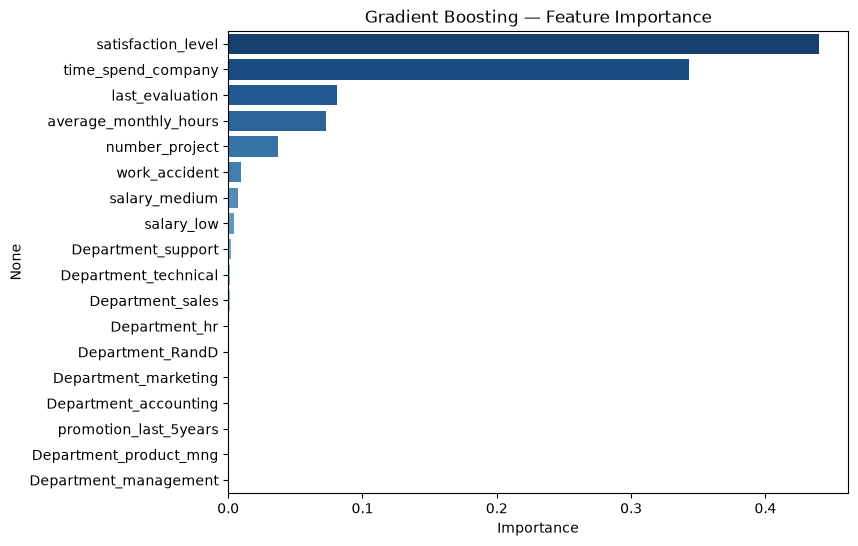

satisfaction_level        0.439627
time_spend_company        0.342886
last_evaluation           0.080753
average_monthly_hours     0.073072
number_project            0.036862
work_accident             0.009798
salary_medium             0.007014
salary_low                0.004282
Department_support        0.001884
Department_technical      0.001358
Department_sales          0.001181
Department_hr             0.000537
Department_RandD          0.000325
Department_marketing      0.000269
Department_accounting     0.000133
promotion_last_5years     0.000018
Department_product_mng    0.000000
Department_management     0.000000
dtype: float64

In [26]:
importances = pd.Series(gbc.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='Blues_r', legend=False)
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Importance')
plt.show()

importances


### 6.5\* Precision-recall curve

*Supplementary analysis — visualizes the precision/recall tradeoff across thresholds for the selected model, supporting the recall-priority decision in 6.3 and connecting to the risk-zone thresholds in Step 7.*

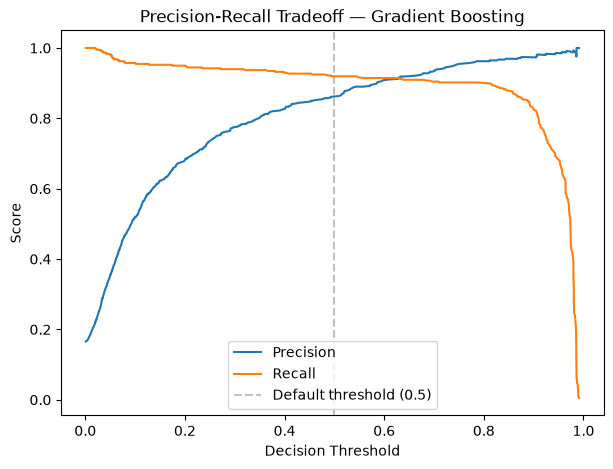

In [27]:
from sklearn.metrics import precision_recall_curve

y_proba_gbc = gbc.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_gbc)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff — Gradient Boosting')
plt.legend()
plt.show()


## 7. Retention strategy by risk zone

### 7.1 Predict turnover probability on the test set


In [28]:
turnover_proba = gbc.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['actual_left'] = y_test.values
risk_df['turnover_probability'] = turnover_proba

risk_df[['actual_left', 'turnover_probability']].head()


,actual_left,turnover_probability
8578,0,0.259678
5756,0,0.743591
3994,0,0.033395
1784,1,0.860409
10508,0,0.075550


### 7.2 Categorize into risk zones


risk_zone
Safe (Green)            1846
Low-Risk (Yellow)        153
Medium-Risk (Orange)      63
High-Risk (Red)          337
Name: count, dtype: int64


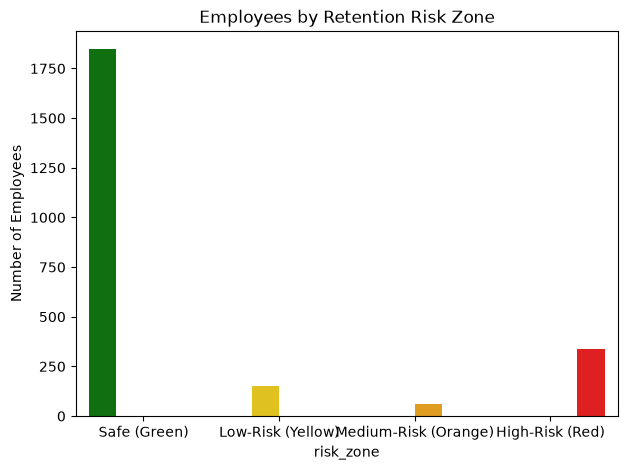

In [29]:
risk_df['risk_zone'] = pd.cut(
    risk_df['turnover_probability'],
    bins=[0, 0.2, 0.6, 0.9, 1.0],
    labels=['Safe (Green)', 'Low-Risk (Yellow)', 'Medium-Risk (Orange)', 'High-Risk (Red)'],
    include_lowest=True
)

zone_counts = risk_df['risk_zone'].value_counts().sort_index()
print(zone_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=risk_df, x='risk_zone', hue='risk_zone', order=zone_counts.index,
              palette=['green', 'gold', 'orange', 'red'], legend=False)
plt.title('Employees by Retention Risk Zone')
plt.ylabel('Number of Employees')
plt.show()


### 7.3 Retention strategy by zone

**Supporting evidence recap:**
- **Feature importance (6.4)** shows `satisfaction_level` (0.44) and `time_spend_company` (0.34) are by far the strongest drivers of the model's predictions — together accounting for over 78% of total importance. `number_project` is real but secondary (0.037), and `salary` and `Department` dummies contribute comparatively little individually, despite the department/salary turnover-rate patterns below.
- **Turnover rate by department and salary (2.4)** shows salary is a strong, clean, monotonic signal: 20.5% turnover at low salary, 14.6% at medium, 4.8% at high. Department differences are much milder (HR highest at 18.8%, management/RandD lowest at ~12%).
- **Step 3 clustering** of employees who left (by satisfaction & evaluation) found 3 distinct profiles, now validated as the right choice by the silhouette score (3.4, highest at k=3): **Red** (low satisfaction 0.11, high evaluation 0.87 — burned-out high performers), **Blue** (high satisfaction 0.81, high evaluation 0.91 — satisfied performers likely leaving for external growth), **Green** (mid satisfaction 0.41, mid evaluation 0.52 — cause unclear from these two features alone).
- **Step 2.3** found `number_project` has a U-shaped relationship with attrition (54% leave at 2 projects, ~1% at 3, climbing back up through 6-7). Combined with the feature importance finding, project count is a real, actionable lever — but it's a *secondary* one behind satisfaction and tenure, not the primary driver.
- **Step 6** established **recall** as the metric that matters most here — the cost of missing an actual leaver (false negative, no intervention happens) far outweighs the cost of flagging a stayer as at-risk (false positive, just some extra unnecessary attention).

**By risk zone:**
- **Safe Zone (Green, <20%):** No action needed for most. Can be a source of slack capacity — if a High-Risk employee is overloaded, consider shifting a project to a Safe-zone employee with room to take on more (targeting the 3-4 project sweet spot for both).
- **Low-Risk Zone (Yellow, 20-60%):** Keep project load largely as-is; light monitoring only, same capacity-donor logic as Safe zone if needed.
- **Medium-Risk Zone (Orange, 60-90%) and High-Risk Zone (Red, >90%):** Since `satisfaction_level` and `time_spend_company` are the dominant drivers, prioritize direct satisfaction check-ins (e.g. stay interviews) and pay attention to long-tenured employees specifically, rather than treating project count as the primary lever. Layer in the secondary, well-evidenced levers:
  - **Project count:** review each employee's load — 5+ projects may benefit from having 1-2 removed, 2 or fewer may benefit from 1-2 more, nudging toward the 3-4 (up to 5) sweet spot.
  - **Salary:** given the clean low→high salary/turnover gradient, a compensation review is a reasonable lever specifically for low-salary employees in these zones.
  - Apply the cluster-specific strategy on top:
    - **Red profile (low satisfaction, high evaluation):** Likely burnout — prioritize workload rebalancing and check for low salary tier.
    - **Blue profile (high satisfaction, high evaluation):** Likely leaving for career growth elsewhere — proactively offer promotion/growth paths before they look outward; freeing their projects also helps rebalance the Red group.
    - **Green profile (mid satisfaction, mid evaluation):** No clear lever from the clustering features alone — flag for direct follow-up (e.g. stay interviews) rather than guessing at an intervention.
